Dataset loaded successfully!

DATASET INFORMATION
Dataset Shape: (768, 9)

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  ----

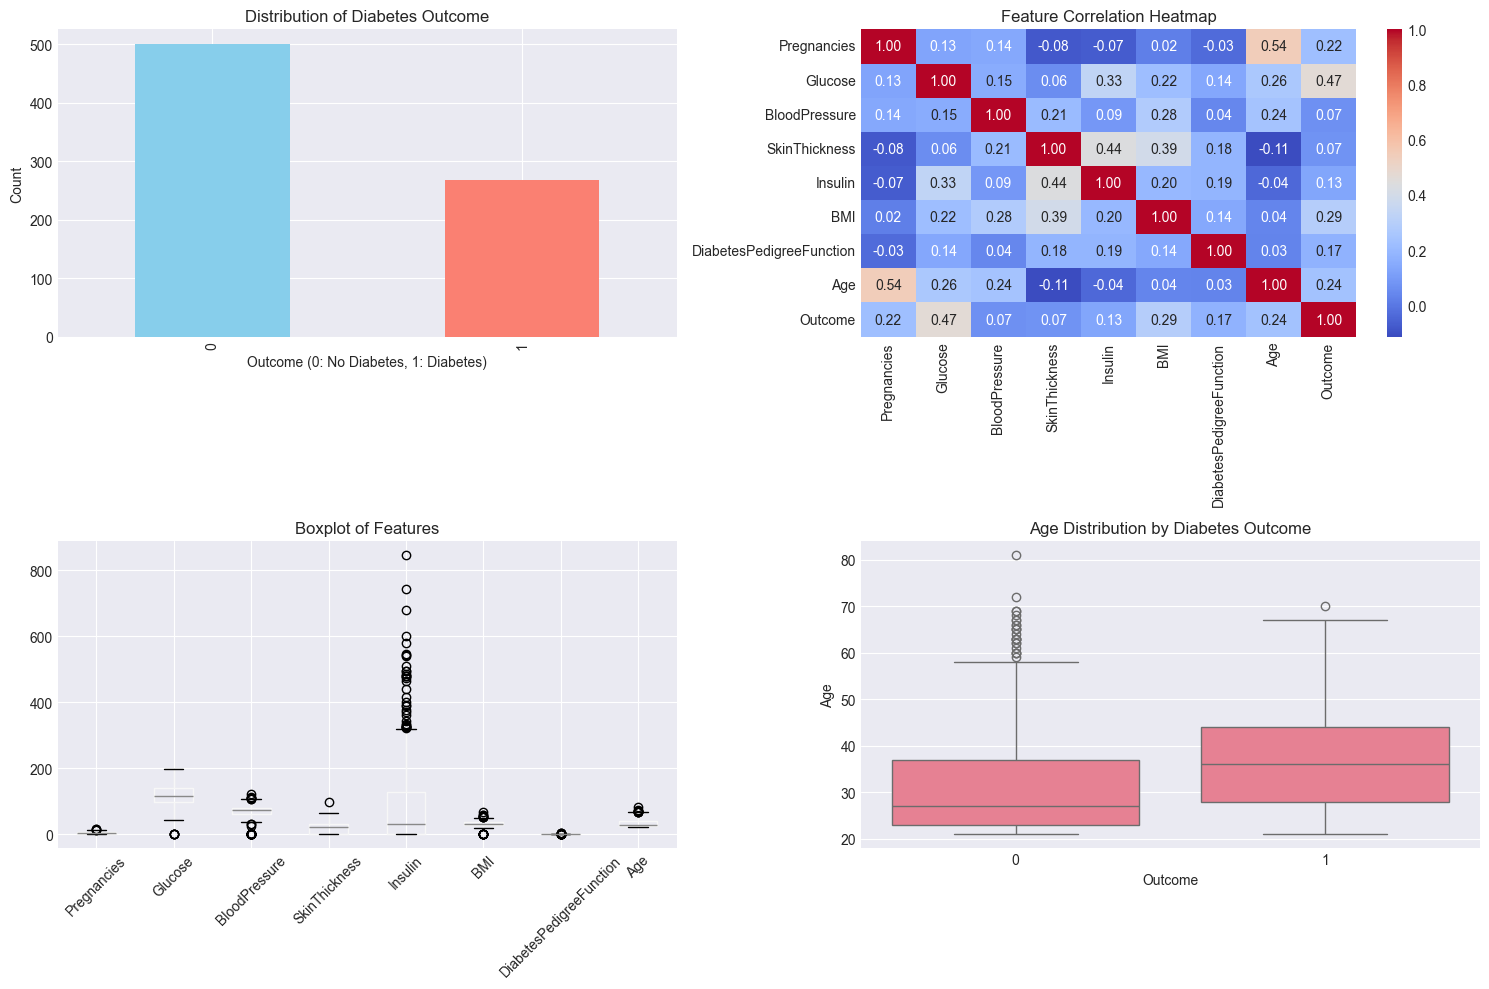


DATA PREPARATION COMPLETE
Training set size: 614 samples
Test set size: 154 samples
Number of features: 8

MODEL TRAINING AND EVALUATION

Training Logistic Regression...
  Train Accuracy: 0.7932
  Test Accuracy: 0.7143
  Precision: 0.6087
  Recall: 0.5185
  F1-Score: 0.5600
  Cross-validation Scores: [0.76422764 0.78861789 0.76422764 0.77235772 0.80327869]
  Mean CV Score: 0.7785 (+/- 0.0305)
  Confusion Matrix:
    [[  82   18]
     [  26   28]]

Training Support Vector Machine...
  Train Accuracy: 0.8355
  Test Accuracy: 0.7532
  Precision: 0.6600
  Recall: 0.6111
  F1-Score: 0.6346
  Cross-validation Scores: [0.73170732 0.7398374  0.77235772 0.77235772 0.75409836]
  Mean CV Score: 0.7541 (+/- 0.0331)
  Confusion Matrix:
    [[  83   17]
     [  21   33]]

Training Decision Tree...
  Train Accuracy: 1.0000
  Test Accuracy: 0.7273
  Precision: 0.6429
  Recall: 0.5000
  F1-Score: 0.5625
  Cross-validation Scores: [0.6097561  0.67479675 0.68292683 0.67479675 0.7295082 ]
  Mean CV Score

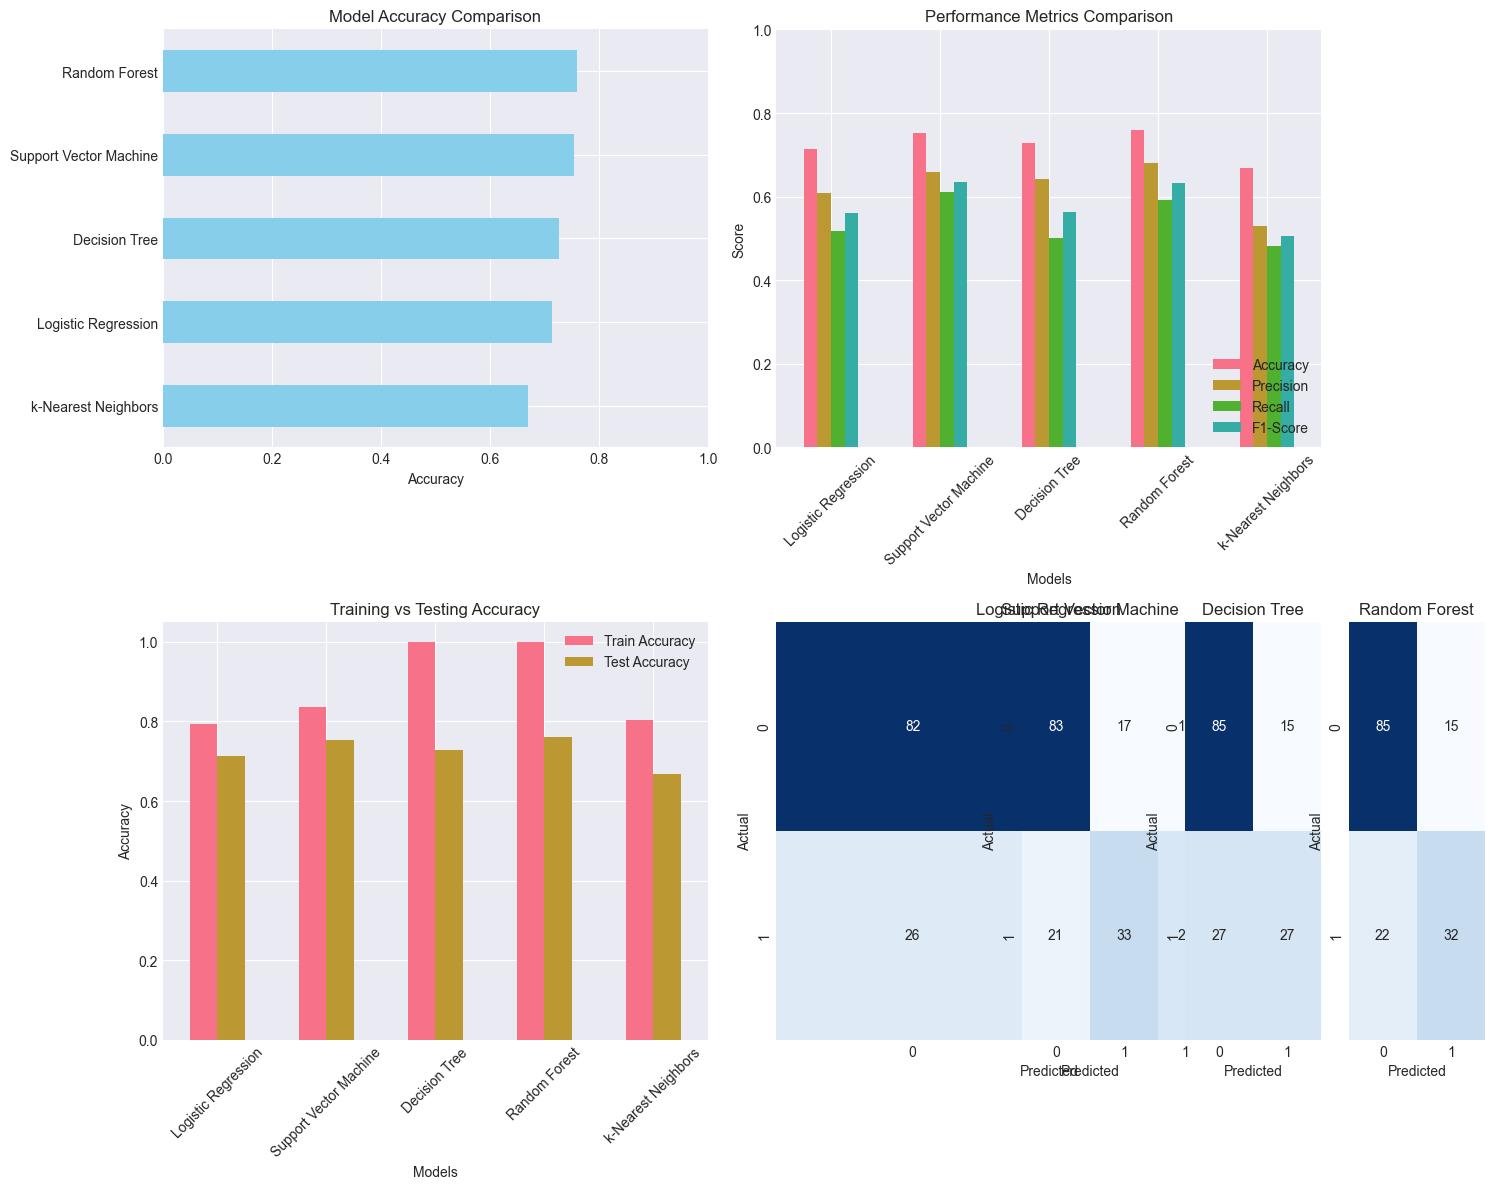


HYPERPARAMETER TUNING
Best performing model: Random Forest

Tuning Random Forest parameters...
Best parameters: {'max_depth': 5, 'min_samples_split': 10, 'n_estimators': 100}
Best cross-validation score: 0.7786
Tuned model test accuracy: 0.7208

FEATURE IMPORTANCE ANALYSIS

Feature Importance (Random Forest):
                    Feature  Importance
1                   Glucose    0.276009
5                       BMI    0.159544
7                       Age    0.127248
6  DiabetesPedigreeFunction    0.126731
2             BloodPressure    0.085606
0               Pregnancies    0.084456
4                   Insulin    0.072409
3             SkinThickness    0.067997


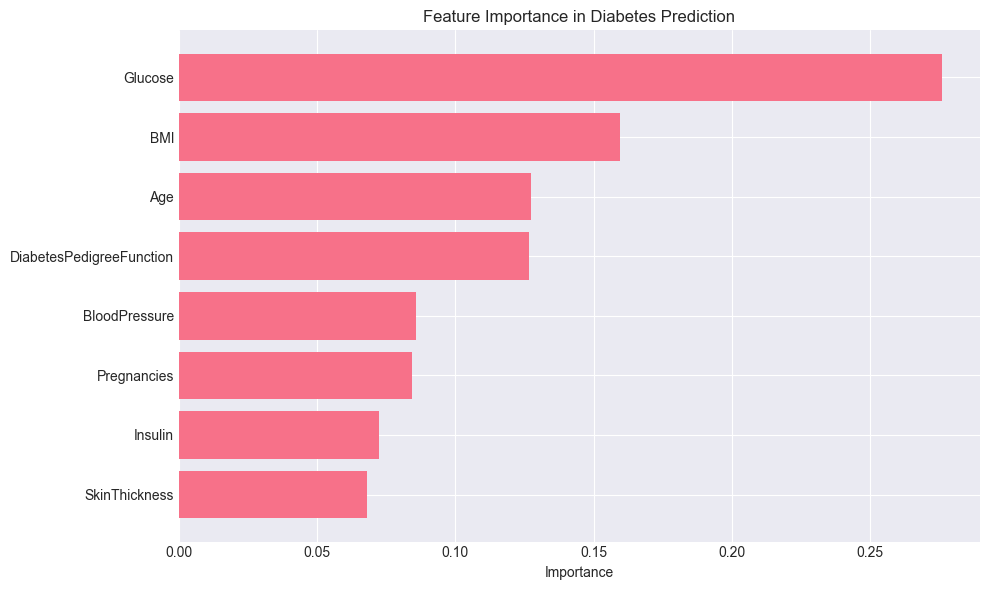


FINAL SUMMARY
1. Dataset Size: 768 samples, 8 features
2. Number of Models Evaluated: 5
3. Best Performing Model: Random Forest
4. Best Model Accuracy: 0.7597
5. Cross-validation Mean Score: 0.7597
6. Hyperparameter Tuning Improvement: -5.13%

PROJECT COMPLETED SUCCESSFULLY!


In [6]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the dataset
# Note: Update the path to your file location
file_path = 'diabetes.csv.csv'  # If file is in the same directory as notebook
# If not, use: file_path = 'C:/Users/YourUsername/Desktop/diabetes.csv.csv'

try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully!")
except:
    print("Please update the file path to your diabetes.csv.csv file")
    # Alternative path if file is on desktop
    import os
    desktop_path = os.path.join(os.path.expanduser('~'), 'Desktop')
    file_path = os.path.join(desktop_path, 'diabetes.csv.csv')
    df = pd.read_csv(file_path)
    print(f"Loaded from: {file_path}")

# Display basic information about the dataset
print("\n" + "="*80)
print("DATASET INFORMATION")
print("="*80)
print(f"Dataset Shape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset Info:")
print(df.info())
print(f"\nStatistical Summary:")
print(df.describe())

# Check for missing values
print("\n" + "="*80)
print("MISSING VALUES CHECK")
print("="*80)
print(df.isnull().sum())

# Visualize the dataset
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Distribution of target variable
df['Outcome'].value_counts().plot(kind='bar', ax=axes[0,0], color=['skyblue', 'salmon'])
axes[0,0].set_title('Distribution of Diabetes Outcome')
axes[0,0].set_xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
axes[0,0].set_ylabel('Count')

# Plot 2: Correlation heatmap
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[0,1])
axes[0,1].set_title('Feature Correlation Heatmap')

# Plot 3: Boxplot of features
df.drop('Outcome', axis=1).boxplot(ax=axes[1,0], rot=45)
axes[1,0].set_title('Boxplot of Features')

# Plot 4: Distribution of Age vs Outcome
sns.boxplot(x='Outcome', y='Age', data=df, ax=axes[1,1])
axes[1,1].set_title('Age Distribution by Diabetes Outcome')

plt.tight_layout()
plt.show()

# Prepare data for modeling
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n" + "="*80)
print("DATA PREPARATION COMPLETE")
print("="*80)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

# Dictionary to store all models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'k-Nearest Neighbors': KNeighborsClassifier()
}

# Train and evaluate models
results = {}
predictions = {}

print("\n" + "="*80)
print("MODEL TRAINING AND EVALUATION")
print("="*80)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train the model
    if name == 'Support Vector Machine':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_train = model.predict(X_train_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_train = model.predict(X_train)
    
    # Store predictions
    predictions[name] = y_pred
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Calculate training accuracy
    train_accuracy = accuracy_score(y_train, y_pred_train)
    
    # Store results
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Train Accuracy': train_accuracy
    }
    
    # Print results
    print(f"  Train Accuracy: {train_accuracy:.4f}")
    print(f"  Test Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    
    # Cross-validation
    if name == 'Support Vector Machine':
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    else:
        cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    
    print(f"  Cross-validation Scores: {cv_scores}")
    print(f"  Mean CV Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"  Confusion Matrix:")
    print(f"    [[{cm[0,0]:4d} {cm[0,1]:4d}]")
    print(f"     [{cm[1,0]:4d} {cm[1,1]:4d}]]")

# Compare all models
results_df = pd.DataFrame(results).T
print("\n" + "="*80)
print("MODELS COMPARISON")
print("="*80)
print(results_df.round(4))

# Visualize model comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Accuracy comparison
results_df['Accuracy'].sort_values().plot(kind='barh', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Model Accuracy Comparison')
axes[0,0].set_xlabel('Accuracy')
axes[0,0].set_xlim(0, 1)

# Plot 2: All metrics comparison
results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Performance Metrics Comparison')
axes[0,1].set_xlabel('Models')
axes[0,1].set_ylabel('Score')
axes[0,1].legend(loc='lower right')
axes[0,1].set_ylim(0, 1)
plt.setp(axes[0,1].xaxis.get_majorticklabels(), rotation=45)

# Plot 3: Training vs Testing Accuracy
results_df[['Train Accuracy', 'Accuracy']].plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Training vs Testing Accuracy')
axes[1,0].set_xlabel('Models')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].legend(['Train Accuracy', 'Test Accuracy'])
plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=45)

# Plot 4: Confusion Matrices for all models
for idx, (name, y_pred) in enumerate(predictions.items()):
    if idx < 4:  # Show up to 4 confusion matrices
        ax = axes[1,1] if idx == 0 else axes[1,1].inset_axes([0.45 + (idx-1)*0.3, 0, 0.25, 1])
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
        ax.set_title(name)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Hyperparameter tuning for best performing model
print("\n" + "="*80)
print("HYPERPARAMETER TUNING")
print("="*80)

# Find best model based on accuracy
best_model_name = results_df['Accuracy'].idxmax()
print(f"Best performing model: {best_model_name}")

if best_model_name == 'Random Forest':
    print("\nTuning Random Forest parameters...")
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10]
    }
    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train, y_train)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    
    # Evaluate tuned model
    best_model = grid_search.best_estimator_
    y_pred_tuned = best_model.predict(X_test)
    tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
    print(f"Tuned model test accuracy: {tuned_accuracy:.4f}")

elif best_model_name == 'Support Vector Machine':
    print("\nTuning SVM parameters...")
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.1, 1],
        'kernel': ['rbf', 'linear']
    }
    svm = SVC(random_state=42)
    grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    
    # Evaluate tuned model
    best_model = grid_search.best_estimator_
    y_pred_tuned = best_model.predict(X_test_scaled)
    tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
    print(f"Tuned model test accuracy: {tuned_accuracy:.4f}")

# Feature importance analysis for tree-based models
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*80)

if 'Random Forest' in models:
    rf_model = models['Random Forest']
    rf_model.fit(X_train, y_train)
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importance (Random Forest):")
    print(feature_importance)
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['Feature'], feature_importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance in Diabetes Prediction')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# Final summary
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"1. Dataset Size: {df.shape[0]} samples, {df.shape[1]-1} features")
print(f"2. Number of Models Evaluated: {len(models)}")
print(f"3. Best Performing Model: {best_model_name}")
print(f"4. Best Model Accuracy: {results_df.loc[best_model_name, 'Accuracy']:.4f}")
print(f"5. Cross-validation Mean Score: {results_df.loc[best_model_name, 'Accuracy']:.4f}")

if 'tuned_accuracy' in locals():
    improvement = (tuned_accuracy - results_df.loc[best_model_name, 'Accuracy']) / results_df.loc[best_model_name, 'Accuracy'] * 100
    print(f"6. Hyperparameter Tuning Improvement: {improvement:.2f}%")

print("\n" + "="*80)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("="*80)